# 03 - Model Training and Results

This notebook trains the Retail Price Optimizer model using the prepared
`feature_engineered_dataset.csv` file from the `data_prep` branch.

The target variable is `price` in Brazilian Reals (BRL). The notebook compares
Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor,
then saves the measured results, figures, final model, and an HTML summary.

In [1]:
from __future__ import annotations

import base64
import json
import math
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "dataset").exists() and (ROOT.parent / "dataset").exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "dataset" / "feature_engineered_dataset.csv"
REPORTS_DIR = ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = ROOT / "models"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Dataset:", DATA_PATH)


Project root: C:\Users\gosfe\OneDrive\University\Third year\Second Semester\Machine Learning\Project repo
Dataset: C:\Users\gosfe\OneDrive\University\Third year\Second Semester\Machine Learning\Project repo\dataset\feature_engineered_dataset.csv


## 1. Load Prepared Data

In [2]:
# Load the feature-engineered dataset prepared by the data-preparation team.
# This is the main modeling table used for training the price optimizer.
df = pd.read_csv(DATA_PATH)

# No extra columns are merged here. The model uses the prepared features that
# already exist in feature_engineered_dataset.csv.
print("Rows and columns in prepared dataset:", df.shape)
display(df.head())


Rows and columns in prepared dataset: (107529, 35)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,freight_ratio_percent,product_volume_cm3,price_range,freight_level,product_size_level,product_demand_count,category_demand_count,category_avg_price,category_median_price,price_vs_category_median
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,22.56%,3528.0,Low,Medium Freight,Small,9,3685,154.382882,129.80,-70.90
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,8.31%,60000.0,High,Medium Freight,Large,1,1913,102.677632,89.70,150.20
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,8.98%,14157.0,Medium,Medium Freight,Large,3,8144,85.398621,65.49,133.51
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,98.46%,2400.0,Very Low,Medium Freight,Small,2,3340,116.809775,84.99,-72.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,9.07%,42000.0,Medium,Medium Freight,Large,11,4211,91.526701,59.90,140.00


In [3]:
# These columns were created during feature engineering, but they use the
# target price directly or summarize the target by category. Keeping them in
# training would cause data leakage and make the model look unrealistically good.
leakage_columns_excluded = [
    "total_order_item_value",
    "freight_ratio",
    "freight_ratio_percent",
    "price_range",
    "category_avg_price",
    "category_median_price",
    "price_vs_category_median",
]

dataset_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "target": "price",
    "price_min": float(df["price"].min()),
    "price_mean": float(df["price"].mean()),
    "price_median": float(df["price"].median()),
    "price_max": float(df["price"].max()),
    "categories": int(df["product_category_name_english"].nunique()),
    "excluded_target_leakage_columns": ", ".join(leakage_columns_excluded),
}
display(pd.DataFrame([dataset_summary]).T.rename(columns={0: "value"}))


,value
rows,107529
columns,35
target,price
price_min,0.85
price_mean,107.020402
price_median,72.99
price_max,887.0
categories,71
excluded_target_leakage_columns,"total_order_item_value, freight_ratio, freight..."


## 2. Select Safe Prepared Features

In [4]:
# Do not create new training features in this notebook. The goal here is to
# use only the feature-engineered columns prepared in the data-prep branch,
# while excluding target-derived leakage columns listed above.
df = df.replace([np.inf, -np.inf], np.nan)

# Numeric predictors used by the model. The engineered fields from the
# prepared CSV include product_volume_cm3, product_demand_count, and
# category_demand_count.
numeric_features = [
    "order_item_id",
    "freight_value",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_volume_cm3",
    "product_demand_count",
    "category_demand_count",
]

# Categorical predictors are handled with one-hot encoding. Product category
# captures market segment, while freight/product levels are engineered groups
# already present in the prepared dataset.
categorical_features = [
    "product_category_name_english",
    "freight_level",
    "product_size_level",
]

model_df = df[numeric_features + categorical_features + ["price"]].copy()
model_df = model_df.dropna(subset=["price"])

X = model_df[numeric_features + categorical_features]
y = model_df["price"]

print("Modeling rows:", len(model_df))
print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Excluded target-derived columns:", leakage_columns_excluded)


Modeling rows: 107529
Numeric features: 12
Categorical features: ['product_category_name_english', 'freight_level', 'product_size_level']
Excluded target-derived columns: ['total_order_item_value', 'freight_ratio', 'freight_ratio_percent', 'price_range', 'category_avg_price', 'category_median_price', 'price_vs_category_median']


In [5]:
stats_table = y.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("price_brl")
display(stats_table)

numeric_corr = model_df[numeric_features + ["price"]].corr(numeric_only=True)["price"].drop("price").sort_values(key=lambda s: s.abs(), ascending=False)
display(numeric_corr.head(12).to_frame("correlation_with_price"))


,price_brl
count,107529.000000
mean,107.020402
std,111.692470
min,0.850000
25%,39.900000
50%,72.990000
75%,129.990000
95%,314.970000
99%,614.407600
max,887.000000


,correlation_with_price
freight_value,0.384178
product_weight_g,0.365416
product_volume_cm3,0.316023
product_height_cm,0.249327
product_width_cm,0.194732
product_length_cm,0.170558
product_description_lenght,0.167596
order_item_id,-0.077619
product_demand_count,-0.064046
category_demand_count,-0.053520


## 3. Train/Test Split and Preprocessing

In [6]:
# Use a fixed 70/30 split so all models are evaluated on the same unseen
# holdout test set and the run is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.70,
    random_state=RANDOM_STATE,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

def make_ohe():
    # min_frequency groups rare categories together when supported by the
    # installed scikit-learn version, reducing noisy one-hot columns.
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# Tree models do not need numeric scaling; median imputation handles missing
# numeric values and one-hot encoding handles categorical values.
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", make_ohe(), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Linear Regression is used as a baseline. Numeric scaling is added only here
# because linear models are sensitive to feature scale.
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", make_ohe(), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


Training rows: 75270
Testing rows: 32259


## 4. Hyperparameter Search

In [7]:
# Grid search is run on a 6,000-row sample to keep runtime practical while
# still comparing meaningful model settings. The final selected models are
# trained later on the full training split.
tune_size = min(6000, len(X_train))
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=tune_size,
    random_state=RANDOM_STATE,
)

# Two-fold cross-validation is used inside GridSearchCV for fast model
# selection. A separate 10-fold validation check is performed after training.
cv_search = KFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

# Random Forest averages many decision trees and is strong for nonlinear
# tabular data such as product, freight, category, demand, and size features.
rf_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

# Gradient Boosting builds trees sequentially, with each new tree correcting
# previous errors. It is tested as a second ensemble learning method.
gb_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

# Random Forest values tested:
# - n_estimators: 80, 140
# - max_depth: 14, None
# - min_samples_leaf: 1
rf_grid = {
    "model__n_estimators": [80, 140],
    "model__max_depth": [14, None],
    "model__min_samples_leaf": [1],
}

# Gradient Boosting values tested:
# - n_estimators: 80, 140
# - learning_rate: 0.05, 0.10
# - max_depth: 2
gb_grid = {
    "model__n_estimators": [80, 140],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2],
}

searches = {}
for name, pipeline, grid in [
    ("Random Forest Regressor", rf_pipeline, rf_grid),
    ("Gradient Boosting Regressor", gb_pipeline, gb_grid),
]:
    print(f"Running GridSearchCV for {name} on {tune_size:,} training rows...")
    search = GridSearchCV(
        pipeline,
        grid,
        # Negative MAE is used because scikit-learn maximizes scores; the
        # selected model is therefore the one with the lowest validation MAE.
        scoring="neg_mean_absolute_error",
        cv=cv_search,
        n_jobs=1,
        verbose=1,
    )
    search.fit(X_tune, y_tune)
    searches[name] = search
    print("Best MAE:", round(-search.best_score_, 4))
    print("Best params:", search.best_params_)


Running GridSearchCV for Random Forest Regressor on 6,000 training rows...
Fitting 2 folds for each of 4 candidates, totalling 8 fits


Best MAE: 48.342
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 140}
Running GridSearchCV for Gradient Boosting Regressor on 6,000 training rows...
Fitting 2 folds for each of 4 candidates, totalling 8 fits


Best MAE: 55.2229
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 140}


## 5. Final Model Training and Holdout Evaluation

In [8]:
# Final evaluation compares one simple baseline against the two tuned
# ensemble models. All three are trained on the same training rows and tested
# on the same untouched holdout rows.
final_models = {
    "Linear Regression Baseline": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LinearRegression()),
    ]),
    "Random Forest Regressor": searches["Random Forest Regressor"].best_estimator_,
    "Gradient Boosting Regressor": searches["Gradient Boosting Regressor"].best_estimator_,
}

fitted_models = {}
results = []

for name, model in final_models.items():
    print(f"Training final {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    # MAE and RMSE are in BRL. R2 measures the share of target-price variance
    # explained by the model.
    metrics = {
        "Technique": name,
        "MAE (BRL)": mean_absolute_error(y_test, pred),
        "RMSE (BRL)": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }
    fitted_models[name] = model
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("MAE (BRL)").reset_index(drop=True)
display(results_df.style.format({"MAE (BRL)": "{:.3f}", "RMSE (BRL)": "{:.3f}", "R2": "{:.4f}"}))

best_model_name = results_df.iloc[0]["Technique"]
best_model = fitted_models[best_model_name]
# Keep predictions from the best model for residual and predicted-vs-actual plots.
best_predictions = best_model.predict(X_test)
print("Best model:", best_model_name)


Training final Linear Regression Baseline...


Training final Random Forest Regressor...


Training final Gradient Boosting Regressor...


,Technique,MAE (BRL),RMSE (BRL),R2
0,Random Forest Regressor,22.544,53.092,0.7753
1,Gradient Boosting Regressor,52.893,87.292,0.3926
2,Linear Regression Baseline,57.856,92.848,0.3128


Best model: Random Forest Regressor


## 6. Cross-Validation Check

In [9]:
# The 10-fold check uses a sampled dataset to provide stronger validation than
# one train/test split while avoiding a very long runtime on the full dataset.
cv_sample_size = min(12000, len(X))
X_cv, _, y_cv, _ = train_test_split(
    X,
    y,
    train_size=cv_sample_size,
    random_state=RANDOM_STATE,
)
cv10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name in ["Random Forest Regressor", "Gradient Boosting Regressor"]:
    print(f"Running 10-fold cross-validation for {name} on {cv_sample_size:,} sampled rows...")
    scores = cross_validate(
        fitted_models[name],
        X_cv,
        y_cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2",
        },
        cv=cv10,
        n_jobs=1,
        return_train_score=False,
    )
    cv_rows.append({
        "Technique": name,
        "CV Rows": int(cv_sample_size),
        "CV MAE Mean": -scores["test_MAE"].mean(),
        "CV MAE Std": scores["test_MAE"].std(),
        "CV RMSE Mean": -scores["test_RMSE"].mean(),
        "CV RMSE Std": scores["test_RMSE"].std(),
        "CV R2 Mean": scores["test_R2"].mean(),
        "CV R2 Std": scores["test_R2"].std(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV MAE Mean").reset_index(drop=True)
display(cv_results_df.style.format({
    "CV MAE Mean": "{:.3f}",
    "CV MAE Std": "{:.3f}",
    "CV RMSE Mean": "{:.3f}",
    "CV RMSE Std": "{:.3f}",
    "CV R2 Mean": "{:.4f}",
    "CV R2 Std": "{:.4f}",
}))


Running 10-fold cross-validation for Random Forest Regressor on 12,000 sampled rows...


Running 10-fold cross-validation for Gradient Boosting Regressor on 12,000 sampled rows...


,Technique,CV Rows,CV MAE Mean,CV MAE Std,CV RMSE Mean,CV RMSE Std,CV R2 Mean,CV R2 Std
0,Random Forest Regressor,12000,39.287,1.685,75.390,4.283,0.5502,0.0310
1,Gradient Boosting Regressor,12000,54.039,1.501,88.375,3.506,0.3819,0.0244


## 7. Feature Selection Experiment

In [10]:
# Model-based feature selection: use the best model's importance scores to
# compare all features against smaller, easier-to-explain feature groups.
preprocess_fitted = best_model.named_steps["preprocess"]
transformed_feature_names = preprocess_fitted.get_feature_names_out()
model_part = best_model.named_steps["model"]

if hasattr(model_part, "feature_importances_"):
    importance_values = model_part.feature_importances_
else:
    importance_values = np.abs(getattr(model_part, "coef_", np.zeros(len(transformed_feature_names))))

feature_importance_df = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": importance_values,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

top_original_numeric = (
    feature_importance_df[feature_importance_df["feature"].isin(numeric_features)]
    .head(8)["feature"]
    .tolist()
)
if len(top_original_numeric) < 5:
    top_original_numeric = numeric_corr.head(8).index.tolist()

feature_subset_rows = []
# Feature subsets tested:
# 1) all cleaned features
# 2) top numeric predictors only
# 3) top numeric predictors + product category
# 4) top numeric predictors + all prepared categorical groups
subset_configs = [
    ("All cleaned features", numeric_features, categorical_features),
    ("Top numeric predictors only", top_original_numeric, []),
    ("Top numeric + product category", top_original_numeric, ["product_category_name_english"]),
    ("Top numeric + prepared categorical features", top_original_numeric, categorical_features),
]

for subset_name, nums, cats in subset_configs:
    subset_preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), nums),
            ("cat", make_ohe(), cats),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    if best_model_name == "Random Forest Regressor":
        subset_regressor = RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **{
                key.replace("model__", ""): value
                for key, value in searches["Random Forest Regressor"].best_params_.items()
            },
        )
    else:
        subset_regressor = GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            **{
                key.replace("model__", ""): value
                for key, value in searches["Gradient Boosting Regressor"].best_params_.items()
            },
        )
    subset_model = Pipeline([
        ("preprocess", subset_preprocessor),
        ("model", subset_regressor),
    ])
    subset_columns = nums + cats
    # Refit the best model type with each feature subset and compare the same
    # holdout metrics. This shows whether fewer features can improve accuracy.
    subset_model.fit(X_train[subset_columns], y_train)
    subset_pred = subset_model.predict(X_test[subset_columns])
    feature_subset_rows.append({
        "Feature Subset": subset_name,
        "Technique": best_model_name,
        "Number of Input Columns": len(subset_columns),
        "MAE": mean_absolute_error(y_test, subset_pred),
        "RMSE": root_mean_squared_error(y_test, subset_pred),
        "R2": r2_score(y_test, subset_pred),
    })

feature_subset_df = pd.DataFrame(feature_subset_rows).sort_values("MAE").reset_index(drop=True)
display(feature_subset_df.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R2": "{:.4f}"}))


,feature,importance
0,freight_value,0.202026
1,product_weight_g,0.145501
2,product_description_lenght,0.101484
3,product_demand_count,0.066075
4,product_volume_cm3,0.057569
5,product_height_cm,0.054600
6,product_name_lenght,0.051497
7,product_length_cm,0.049352
8,product_width_cm,0.042989
9,category_demand_count,0.036604


,Feature Subset,Technique,Number of Input Columns,MAE,RMSE,R2
0,All cleaned features,Random Forest Regressor,15,22.544,53.092,0.7753
1,Top numeric + product category,Random Forest Regressor,9,22.883,54.219,0.7657
2,Top numeric + prepared categorical features,Random Forest Regressor,11,22.944,54.315,0.7648
3,Top numeric predictors only,Random Forest Regressor,8,26.585,60.219,0.7109


## 8. Plots and Saved Artifacts

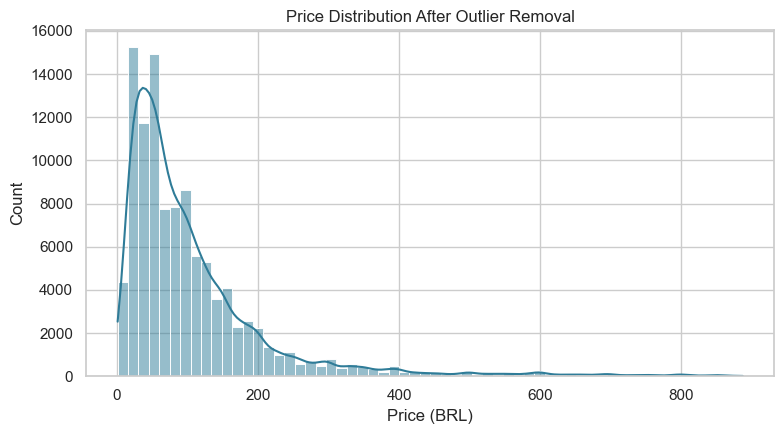

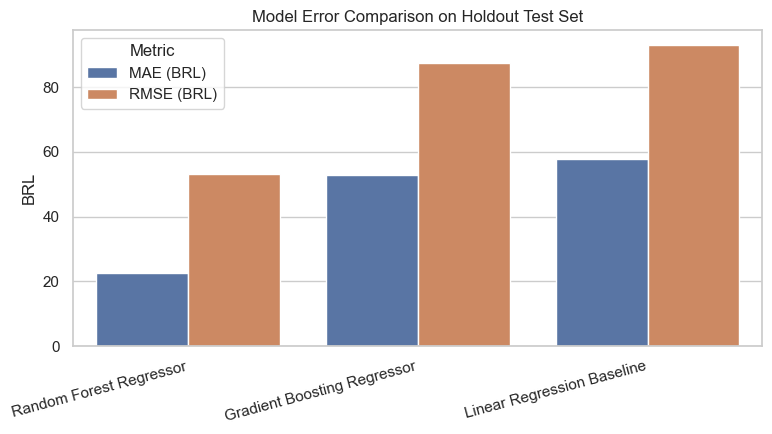

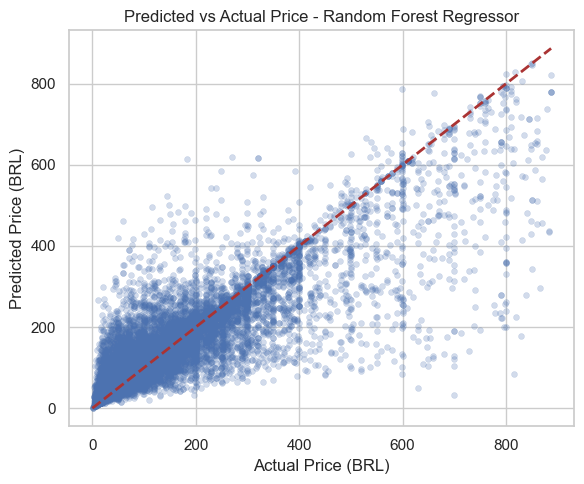

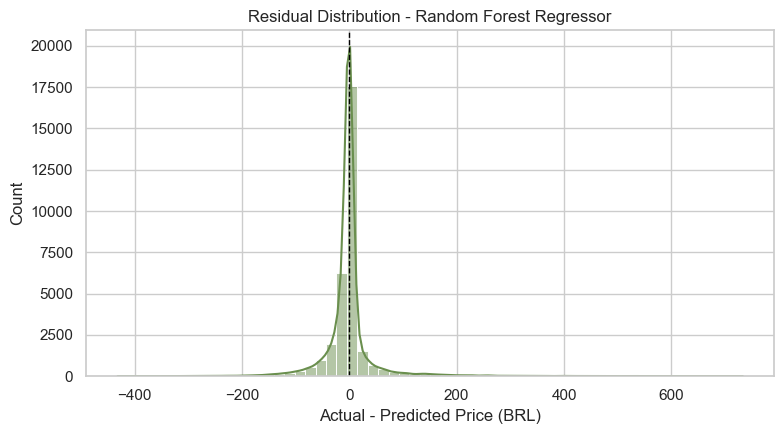

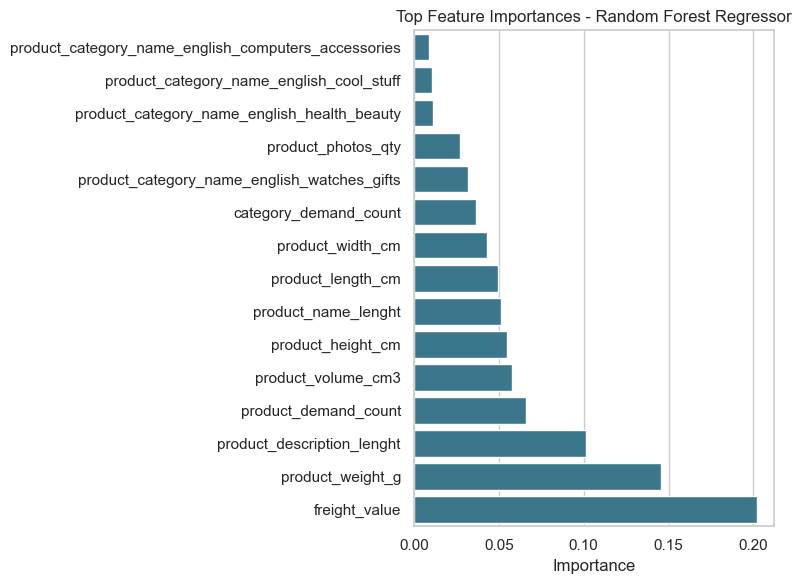

In [11]:
def savefig(name: str):
    # Save every figure to reports/figures so the notebook, HTML page, and
    # final report can all reference the same artifacts.
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

figure_paths = {}

plt.figure(figsize=(8, 4.5))
sns.histplot(y, bins=60, kde=True, color="#2f7c98")
plt.title("Price Distribution After Outlier Removal")
plt.xlabel("Price (BRL)")
plt.ylabel("Count")
figure_paths["price_distribution"] = savefig("price_distribution.png")

plt.figure(figsize=(8, 4.5))
plot_df = results_df.melt(id_vars="Technique", value_vars=["MAE (BRL)", "RMSE (BRL)"], var_name="Metric", value_name="Value")
sns.barplot(data=plot_df, x="Technique", y="Value", hue="Metric")
plt.title("Model Error Comparison on Holdout Test Set")
plt.xlabel("")
plt.ylabel("BRL")
plt.xticks(rotation=15, ha="right")
figure_paths["model_error_comparison"] = savefig("model_error_comparison.png")

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.25, s=18, edgecolor=None)
max_val = max(float(y_test.max()), float(np.max(best_predictions)))
plt.plot([0, max_val], [0, max_val], color="#a33", linestyle="--", linewidth=2)
plt.title(f"Predicted vs Actual Price - {best_model_name}")
plt.xlabel("Actual Price (BRL)")
plt.ylabel("Predicted Price (BRL)")
figure_paths["predicted_vs_actual"] = savefig("predicted_vs_actual.png")

residuals = y_test - best_predictions
plt.figure(figsize=(8, 4.5))
sns.histplot(residuals, bins=60, kde=True, color="#6a8f4e")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title(f"Residual Distribution - {best_model_name}")
plt.xlabel("Actual - Predicted Price (BRL)")
plt.ylabel("Count")
figure_paths["residuals"] = savefig("residuals.png")

plt.figure(figsize=(8, 6))
top_features = feature_importance_df.head(15).iloc[::-1]
sns.barplot(data=top_features, x="importance", y="feature", color="#2f7c98")
plt.title(f"Top Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("")
figure_paths["feature_importance"] = savefig("feature_importance.png")


In [12]:
# Store the exact selected parameters, metrics, feature lists, and top
# importance values in JSON/CSV files so the report can be updated
# reproducibly from the notebook results.
best_params = {
    name: {
        key.replace("model__", ""): value
        for key, value in search.best_params_.items()
    }
    for name, search in searches.items()
}

metrics_payload = {
    "run_timestamp": datetime.now().isoformat(timespec="seconds"),
    "dataset": dataset_summary,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "target": "price",
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "excluded_target_leakage_columns": leakage_columns_excluded,
    "best_model": best_model_name,
    "best_params": best_params,
    "holdout_results": results_df.to_dict(orient="records"),
    "cross_validation_results": cv_results_df.to_dict(orient="records"),
    "feature_subset_results": feature_subset_df.to_dict(orient="records"),
    "top_features": feature_importance_df.head(20).to_dict(orient="records"),
    "figures": {key: str(value.relative_to(ROOT)) for key, value in figure_paths.items()},
}

results_df.to_csv(REPORTS_DIR / "model_performance.csv", index=False)
cv_results_df.to_csv(REPORTS_DIR / "cross_validation_results.csv", index=False)
feature_subset_df.to_csv(REPORTS_DIR / "feature_subset_results.csv", index=False)
feature_importance_df.to_csv(REPORTS_DIR / "feature_importance.csv", index=False)

with open(REPORTS_DIR / "model_training_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

joblib.dump(best_model, MODELS_DIR / "best_price_model.joblib")

# The saved model is a full scikit-learn Pipeline, so it includes both
# preprocessing and the trained regressor.
print("Saved metrics to", REPORTS_DIR / "model_training_metrics.json")
print("Saved best model to", MODELS_DIR / "best_price_model.joblib")


Saved metrics to C:\Users\gosfe\OneDrive\University\Third year\Second Semester\Machine Learning\Project repo\reports\model_training_metrics.json
Saved best model to C:\Users\gosfe\OneDrive\University\Third year\Second Semester\Machine Learning\Project repo\models\best_price_model.joblib


## 9. HTML Results Page

In [13]:
def image_to_data_uri(path: Path) -> str:
    suffix = path.suffix.lower().replace(".", "")
    mime = "jpeg" if suffix in {"jpg", "jpeg"} else suffix
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:image/{mime};base64,{encoded}"

def table_html(df: pd.DataFrame, float_format="{:.3f}") -> str:
    return df.to_html(index=False, classes="results-table", border=0, float_format=lambda x: float_format.format(x))

best_row = results_df.iloc[0]
html = f'''
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Retail Price Optimizer - Model Training Results</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 0; background: #f6f8fa; color: #1f2933; }}
    header {{ background: #1f5a73; color: white; padding: 30px 42px; }}
    main {{ max-width: 1120px; margin: 0 auto; padding: 28px 22px 52px; }}
    section {{ background: white; border: 1px solid #d8e1e8; border-radius: 8px; padding: 22px; margin-bottom: 22px; }}
    h1, h2 {{ margin-top: 0; }}
    .cards {{ display: grid; grid-template-columns: repeat(4, minmax(0, 1fr)); gap: 14px; }}
    .card {{ background: #eef7fb; border-left: 4px solid #2f7c98; padding: 14px; border-radius: 6px; }}
    .card b {{ display: block; font-size: 13px; color: #475569; margin-bottom: 6px; }}
    .card span {{ font-size: 22px; font-weight: 700; }}
    .results-table {{ width: 100%; border-collapse: collapse; margin: 14px 0; font-size: 14px; }}
    .results-table th {{ background: #1f5a73; color: white; text-align: left; padding: 10px; }}
    .results-table td {{ border-bottom: 1px solid #d8e1e8; padding: 10px; vertical-align: top; }}
    .grid {{ display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 18px; }}
    img {{ max-width: 100%; border: 1px solid #d8e1e8; border-radius: 6px; background: white; }}
    .note {{ color: #536471; line-height: 1.5; }}
    @media (max-width: 760px) {{
      .cards, .grid {{ grid-template-columns: 1fr; }}
      header {{ padding: 24px; }}
    }}
  </style>
</head>
<body>
  <header>
    <h1>Retail Price Optimizer - Model Training Results</h1>
    <p>Executed notebook output generated on {metrics_payload["run_timestamp"]}</p>
  </header>
  <main>
    <section>
      <h2>Best Model Summary</h2>
      <div class="cards">
        <div class="card"><b>Best model</b><span>{best_model_name}</span></div>
        <div class="card"><b>MAE</b><span>{best_row["MAE (BRL)"]:.2f} BRL</span></div>
        <div class="card"><b>RMSE</b><span>{best_row["RMSE (BRL)"]:.2f} BRL</span></div>
        <div class="card"><b>R2</b><span>{best_row["R2"]:.3f}</span></div>
      </div>
      <p class="note">The model was trained using {metrics_payload["train_rows"]:,} training rows and tested using {metrics_payload["test_rows"]:,} holdout rows from the prepared outlier-filtered Olist dataset.</p>
    </section>
    <section>
      <h2>Holdout Test Results</h2>
      {table_html(results_df, "{:.4f}")}
    </section>
    <section>
      <h2>Cross-Validation Results</h2>
      {table_html(cv_results_df, "{:.4f}")}
    </section>
    <section>
      <h2>Feature Selection Experiment</h2>
      {table_html(feature_subset_df, "{:.4f}")}
    </section>
    <section>
      <h2>Plots</h2>
      <div class="grid">
        <img src="{image_to_data_uri(figure_paths["price_distribution"])}" alt="Price distribution">
        <img src="{image_to_data_uri(figure_paths["model_error_comparison"])}" alt="Model error comparison">
        <img src="{image_to_data_uri(figure_paths["predicted_vs_actual"])}" alt="Predicted versus actual price">
        <img src="{image_to_data_uri(figure_paths["feature_importance"])}" alt="Feature importance">
      </div>
    </section>
    <section>
      <h2>Top Features</h2>
      {table_html(feature_importance_df.head(15), "{:.6f}")}
    </section>
  </main>
</body>
</html>
'''

html_path = REPORTS_DIR / "model_training_results.html"
html_path.write_text(html, encoding="utf-8")
print("Saved HTML report to", html_path)
display(HTML(f"<p><b>HTML report saved:</b> {html_path}</p>"))


Saved HTML report to C:\Users\gosfe\OneDrive\University\Third year\Second Semester\Machine Learning\Project repo\reports\model_training_results.html
